# Baseline VLP model - int8 TFLite export

This notebook is a copy of `baseline_vlp.ipynb` that keeps the same simple Task 1 training pipeline, but exports the trained MLP as a fully int8 `.tflite` flatbuffer for Pico deployment. It trains only on `data/train_clean_3x3_1cm.csv` and evaluates on the provided `data/validation_clean_3x3_1cm.csv`.

The notebook demonstrates:

1. loading the fixed cleaned 3x3 training and validation CSVs;
2. scaling RSS values and coordinate targets;
3. training a small MLP;
4. reporting positioning error in centimeters;
5. applying PT2E post-training quantization with calibration samples from the training split;
6. exporting an int8-input/int8-output `.tflite` flatbuffer with LiteRT Torch;
7. checking the quantized TFLite model on the host;
8. exporting the same quantized flatbuffer and scaling constants into the Pico firmware template.


In [1]:
from pathlib import Path
import csv
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from vlp_hackathon.baseline_model import BaselineMLP
from vlp_hackathon.export import tflite_to_c_array
from vlp_hackathon.metrics import euclidean_errors_cm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cu130


## Load the fixed Task 1 train and validation CSVs

Task 1 data are already reduced to Configuration 2. Each CSV contains `x`, `y`, and these nine RSS channels:

```text
[0, 2, 4,
 12, 14, 16,
 24, 26, 28]
```

Coordinates are stored in millimeters and converted to centimeters. The raw 6x6 development dataset is not used for training this baseline.


In [2]:
TRAIN_CSV = ROOT / "data" / "train_clean_3x3_1cm.csv"
VALIDATION_CSV = ROOT / "data" / "validation_clean_3x3_1cm.csv"
CONF1_COLUMNS = ["led_0", "led_1", "led_2", "led_3", "led_4", "led_5",
                 "led_6", "led_7", "led_8", "led_9", "led_10", "led_11",
                 "led_12", "led_13", "led_14", "led_15", "led_16", "led_17",
                 "led_18", "led_19", "led_20", "led_21", "led_22", "led_23",
                 "led_24", "led_25", "led_26", "led_27", "led_28", "led_29",
                 "led_30", "led_31", "led_32", "led_33", "led_34", "led_35"]
CONF2_COLUMNS = ["led_0", "led_2", "led_4", "led_12", "led_14", "led_16", "led_24", "led_26", "led_28"]

def load_task1_csv(path):
    rows = []
    with path.open(newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            rows.append([float(row["x"]), float(row["y"]), *[float(row[c]) for c in CONF2_COLUMNS]])
    arr = np.asarray(rows, dtype=np.float32)
    return arr[:, 2:], arr[:, :2] / 10.0

X_train_raw, y_train_cm = load_task1_csv(TRAIN_CSV)
X_val_raw, y_val_cm = load_task1_csv(VALIDATION_CSV)

print("Training rows:", len(X_train_raw))
print("Validation rows:", len(X_val_raw))
print("Input shape:", X_train_raw.shape)
print("Target x range (cm):", y_train_cm[:, 0].min(), "to", y_train_cm[:, 0].max())
print("Target y range (cm):", y_train_cm[:, 1].min(), "to", y_train_cm[:, 1].max())


Training rows: 42166
Validation rows: 4685
Input shape: (42166, 9)
Target x range (cm): 0.0 to 281.0
Target y range (cm): 0.0 to 275.0


In [3]:
print("Using split files:")
print("  train:", TRAIN_CSV.name, len(X_train_raw), "rows")
print("  validation:", VALIDATION_CSV.name, len(X_val_raw), "rows")

Using split files:
  train: train_clean_3x3_1cm.csv 42166 rows
  validation: validation_clean_3x3_1cm.csv 4685 rows


## Simple preprocessing

The baseline scales RSS inputs by the maximum absolute RSS seen in the clean training view. Coordinate targets are normalized per axis to `[0, 1]`. The same constants are exported into the Pico firmware headers.

RSS scale: 0.8493868112564087
Target min cm: [0. 0.]
Target range cm: [281. 275.]


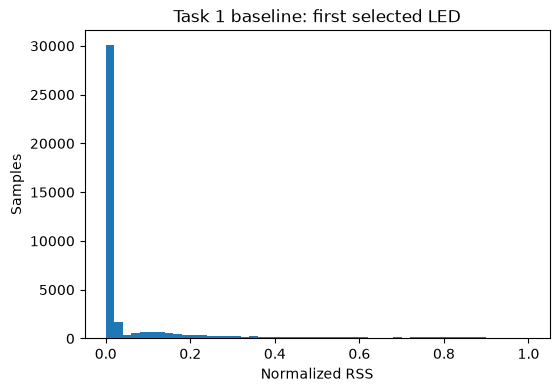

In [4]:
rss_scale = max(float(np.max(np.abs(X_train_raw))), 1e-8)
X_train = X_train_raw / rss_scale
X_val = X_val_raw / rss_scale

target_min_cm = y_train_cm.min(axis=0)
target_range_cm = np.maximum(y_train_cm.max(axis=0) - target_min_cm, 1e-8)
y_train = (y_train_cm - target_min_cm) / target_range_cm
y_val = (y_val_cm - target_min_cm) / target_range_cm

print("RSS scale:", rss_scale)
print("Target min cm:", target_min_cm)
print("Target range cm:", target_range_cm)

plt.figure(figsize=(6, 4))
plt.hist(X_train[:, 0], bins=50)
plt.xlabel("Normalized RSS")
plt.ylabel("Samples")
plt.title("Task 1 baseline: first selected LED")
plt.show()

## Naive baseline MLP

The network is deliberately small and conventional: `9 -> 32 -> 32 -> 2`, with ReLU hidden activations and a sigmoid output. It is a starter baseline and should be improved for your submission.

In [5]:
# You may tune these
lr = 1e-3
epochs = 50
batch_size = 512

In [6]:
model = BaselineMLP(input_features=X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_val_t = torch.from_numpy(X_val)
y_val_t = torch.from_numpy(y_val)
print(model)

BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=2, bias=True)
    (7): Sigmoid()
  )
)


epoch=01 train_mse=0.022547 val_mse=0.003894
epoch=02 train_mse=0.002394 val_mse=0.001167
epoch=03 train_mse=0.000769 val_mse=0.000475
epoch=04 train_mse=0.000391 val_mse=0.000305
epoch=05 train_mse=0.000270 val_mse=0.000219
epoch=06 train_mse=0.000207 val_mse=0.000171
epoch=07 train_mse=0.000167 val_mse=0.000138
epoch=08 train_mse=0.000142 val_mse=0.000119
epoch=09 train_mse=0.000125 val_mse=0.000109
epoch=10 train_mse=0.000108 val_mse=0.000109
epoch=11 train_mse=0.000103 val_mse=0.000085
epoch=12 train_mse=0.000092 val_mse=0.000077
epoch=13 train_mse=0.000082 val_mse=0.000084
epoch=14 train_mse=0.000077 val_mse=0.000089
epoch=15 train_mse=0.000072 val_mse=0.000077
epoch=16 train_mse=0.000068 val_mse=0.000072
epoch=17 train_mse=0.000063 val_mse=0.000069
epoch=18 train_mse=0.000062 val_mse=0.000051
epoch=19 train_mse=0.000059 val_mse=0.000051
epoch=20 train_mse=0.000056 val_mse=0.000043
epoch=21 train_mse=0.000050 val_mse=0.000044
epoch=22 train_mse=0.000052 val_mse=0.000049
epoch=23 t

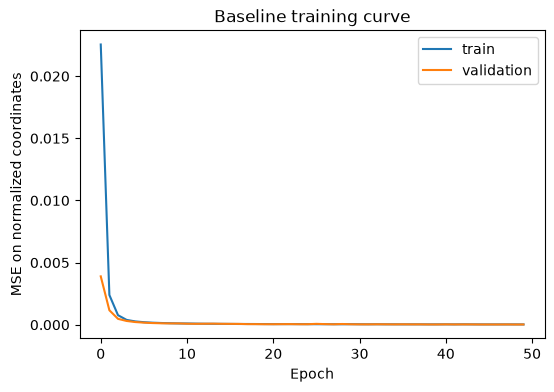

In [7]:
history = []
train_rng = np.random.default_rng(SEED)
for epoch in range(epochs):
    model.train()
    permutation = train_rng.permutation(len(X_train))
    running = 0.0
    for start in range(0, len(permutation), batch_size):
        idx = permutation[start:start + batch_size]
        xb = X_train_t[idx]
        yb = y_train_t[idx]
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += float(loss.item()) * len(idx)

    model.eval()
    with torch.no_grad():
        val_loss = float(loss_fn(model(X_val_t), y_val_t).item())
    history.append((running / len(X_train), val_loss))
    print(f"epoch={epoch + 1:02d} train_mse={history[-1][0]:.6f} val_mse={val_loss:.6f}")

history = np.asarray(history, dtype=np.float32)
plt.figure(figsize=(6, 4))
plt.plot(history[:, 0], label="train")
plt.plot(history[:, 1], label="validation")
plt.xlabel("Epoch")
plt.ylabel("MSE on normalized coordinates")
plt.legend()
plt.title("Baseline training curve")
plt.show()

Float validation mean error:   1.543 cm
Float validation median error: 1.303 cm
Float validation p95 error:    3.607 cm


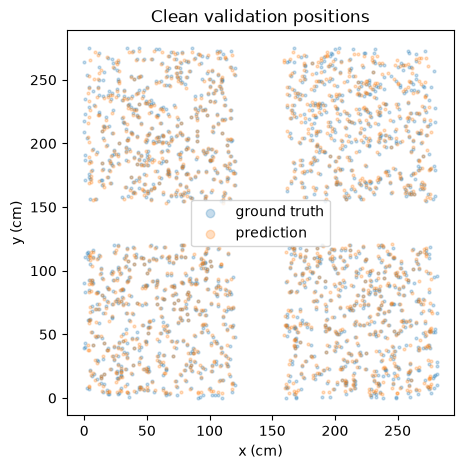

In [8]:
model.eval()
with torch.no_grad():
    float_norm = model(torch.from_numpy(X_val)).numpy()
float_pred_cm = target_min_cm + float_norm * target_range_cm
float_errors = euclidean_errors_cm(float_pred_cm, y_val_cm)

print(f"Float validation mean error:   {float_errors.mean():.3f} cm")
print(f"Float validation median error: {np.median(float_errors):.3f} cm")
print(f"Float validation p95 error:    {np.percentile(float_errors, 95):.3f} cm")

plt.figure(figsize=(5, 5))
n_show = min(1500, len(y_val_cm))
plt.scatter(y_val_cm[:n_show, 0], y_val_cm[:n_show, 1], s=4, alpha=0.25, label="ground truth")
plt.scatter(float_pred_cm[:n_show, 0], float_pred_cm[:n_show, 1], s=4, alpha=0.25, label="prediction")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.legend(markerscale=3)
plt.title("Clean validation positions")
plt.show()

## Save the trained model and export int8 TFLite

The trained PyTorch state is saved first. A small helper is then run in a fresh Python process to apply PT2E post-training quantization, calibrate with the normalized clean training inputs, export an int8 `.tflite` flatbuffer with LiteRT Torch, and copy it into the Pico firmware template.


In [9]:
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)
torch.save(model.state_dict(), models_dir / "baseline_task1_int8.pt")
np.savez(
    models_dir / "baseline_task1_int8_scaling.npz",
    rss_scale=np.asarray(rss_scale, dtype=np.float32),
    target_min_cm=target_min_cm.astype(np.float32),
    target_range_cm=target_range_cm.astype(np.float32),
    train_loss=history,
    float_errors=float_errors.astype(np.float32),
)
print("Saved trained int8 baseline state and scaling constants")


Saved trained int8 baseline state and scaling constants


In [10]:
import subprocess
import sys

export_command = [
    sys.executable,
    str(ROOT / "scripts" / "export_litert_int8_baseline.py"),
]

print("Running int8 LiteRT export helper:")
print(" ".join(export_command))

subprocess.run(
    export_command,
    cwd=ROOT,
    check=True,
)

tflite_path = ROOT / "models" / "baseline_task1_int8.tflite"
assert tflite_path.exists(), f"Export completed but {tflite_path} was not created."

print("Int8 TFLite bytes:", tflite_path.stat().st_size)


Running int8 LiteRT export helper:
/home/derk/Downloads/SYS_AI_VLP_Hackathon/venv/bin/python /home/derk/Downloads/SYS_AI_VLP_Hackathon/scripts/export_litert_int8_baseline.py


I0000 00:00:1783598858.709926   73067 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/derk/Downloads/SYS_AI_VLP_Hackathon/venv/lib/python3.13/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


(00:00) [START] LiteRT-Torch Convert
(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default


(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > 
ExportedProgram Run Decompositions
(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default (+00:00)
(00:00) [START] LiteRT-Torch Convert > Run FX Passes


/home/derk/miniconda3/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:00) [START] LiteRT-Torch Convert > Run FX Passes > ExportedProgram Run 
Decompositions
(00:00) [ DONE] LiteRT-Torch Convert > Run FX Passes > ExportedProgram Run 
Decompositions (+00:00)
(00:00) [ DONE] LiteRT-Torch Convert > Run FX Passes (+00:00)
(00:00) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default
(00:00) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions
(00:00) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:00) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions
(00:00) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:00) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create 
MLIR Module


/home/derk/miniconda3/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/home/derk/Downloads/SYS_AI_VLP_Hackathon/venv/lib/python3.13/site-packages/litert_torch/_convert/signature.py:52: FutureWarning: `treespec.children_specs` is deprecated. Use `treespec.child(index)` to access a single child, or `treespec.children()` to get all children.
  args_spec, kwargs_spec = spec.children_specs
/home/derk/Downloads/SYS_AI_VLP_Hackathon/venv/lib/python3.13/site-packages/litert_torch/_convert/signature.py:58: FutureWarning: `treespec.children_specs` is deprecated. Use `treespec.child(index)` to access a single child, or `treespec.children()` to get all children.
  kwargs_spec.children_specs, kwargs_spec.context


(00:00) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create 
MLIR Module (+00:00)
(00:00) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default (+00:00)
(00:00) [START] LiteRT-Torch Convert > Merge MLIR Modules
(00:00) [ DONE] LiteRT-Torch Convert > Merge MLIR Modules (+00:00)
(00:00) [START] LiteRT-Torch Convert > Run LiteRT Converter Passes
(00:00) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)
(00:00) [ DONE] LiteRT-Torch Convert (+00:00)
(00:00) [START] Write Model to Bytes
(00:00) [ DONE] Write Model to Bytes (+00:00)
Wrote /home/derk/Downloads/SYS_AI_VLP_Hackathon/models/baseline_task1_int8.tflite (122624 bytes)
Wrote /home/derk/Downloads/SYS_AI_VLP_Hackathon/firmware/vlp_serial/vlp_model.tflite
Updated model_data.cc/.h and preprocessing/target scaling headers


I0000 00:00:1783598889.246428   73067 flatbuffer_export.cc:4346] Estimated count of arithmetic ops: 0.202 M  ops, equivalently 0.101 M  MACs


Int8 TFLite bytes: 122624


## Check the exported int8 TFLite model

The same normalized validation vectors are quantized using the input tensor scale and zero point, sent through the exported flatbuffer using the LiteRT interpreter, and then dequantized from the output tensor scale and zero point.


In [11]:
from ai_edge_litert.interpreter import Interpreter

def quantize_tensor(values, tensor_info):
    scale, zero_point = tensor_info["quantization"]
    if scale == 0:
        raise ValueError("Quantized tensor is missing scale information")
    dtype = tensor_info["dtype"]
    q = np.round(values / scale + zero_point)
    q = np.clip(q, np.iinfo(dtype).min, np.iinfo(dtype).max)
    return q.astype(dtype)

def dequantize_tensor(values, tensor_info):
    scale, zero_point = tensor_info["quantization"]
    return (values.astype(np.float32) - zero_point) * scale

tflite_bytes = tflite_path.read_bytes()
interpreter = Interpreter(model_content=tflite_bytes)
interpreter.allocate_tensors()
input_info = interpreter.get_input_details()[0]
output_info = interpreter.get_output_details()[0]

print("Input dtype:", input_info["dtype"], "shape:", input_info["shape"], "quant:", input_info["quantization"])
print("Output dtype:", output_info["dtype"], "shape:", output_info["shape"], "quant:", output_info["quantization"])
assert input_info["dtype"] == np.int8
assert output_info["dtype"] == np.int8

pred_norm = np.empty((len(X_val), 2), dtype=np.float32)
for i, row in enumerate(X_val):
    interpreter.set_tensor(input_info["index"], quantize_tensor(row[None, :], input_info))
    interpreter.invoke()
    pred_norm[i] = dequantize_tensor(interpreter.get_tensor(output_info["index"]), output_info)[0]

tflite_pred_cm = target_min_cm + pred_norm * target_range_cm
tflite_errors = euclidean_errors_cm(tflite_pred_cm, y_val_cm)
print(f"Int8 TFLite validation mean error:   {tflite_errors.mean():.3f} cm")
print(f"Int8 TFLite validation median error: {np.median(tflite_errors):.3f} cm")
print(f"Int8 TFLite validation p95 error:    {np.percentile(tflite_errors, 95):.3f} cm")


Input dtype: <class 'numpy.int8'> shape: [1 9] quant: (0.0037434895057231188, -128)
Output dtype: <class 'numpy.int8'> shape: [1 2] quant: (0.00390625, -128)
Int8 TFLite validation mean error:   1.838 cm
Int8 TFLite validation median error: 1.602 cm
Int8 TFLite validation p95 error:    4.063 cm


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Export directly into the Pico firmware template

The export helper already copies the int8 `.tflite` flatbuffer to the firmware template. The final cell regenerates `model_data.cc`/`.h` from that exact flatbuffer and writes preprocessing and coordinate de-normalization constants. The firmware template accepts float32 requests from the host and internally quantizes them for int8 model I/O.


In [12]:
firmware_dir = ROOT / "firmware" / "vlp_serial"
firmware_tflite = firmware_dir / "vlp_model.tflite"
firmware_tflite.write_bytes(tflite_path.read_bytes())
tflite_to_c_array(
    firmware_tflite,
    firmware_dir / "model_data.cc",
    firmware_dir / "model_data.h",
)

def c_float(value):
    text = f"{float(value):.9g}"
    if "." not in text and "e" not in text.lower():
        text += ".0"
    return text + "f"

(firmware_dir / "preprocess_data.h").write_text(
    "#pragma once\n\n"
    f"constexpr float kRssScale = {c_float(rss_scale)};\n",
    encoding="utf-8",
)
(firmware_dir / "target_scale_data.h").write_text(
    "#pragma once\n\n"
    f"constexpr float kTargetXMinCm = {c_float(target_min_cm[0])};\n"
    f"constexpr float kTargetYMinCm = {c_float(target_min_cm[1])};\n"
    f"constexpr float kTargetXRangeCm = {c_float(target_range_cm[0])};\n"
    f"constexpr float kTargetYRangeCm = {c_float(target_range_cm[1])};\n",
    encoding="utf-8",
)
print("Int8 firmware model and headers updated in:", firmware_dir)


Int8 firmware model and headers updated in: /home/derk/Downloads/SYS_AI_VLP_Hackathon/firmware/vlp_serial
